# Misure rilevanti su un grafo diretto con NetworkX

Questo notebook mostra **solo le misure più utili** per analizzare un **grafo diretto** costruito da una *edge list* e indica **quando una misura è dispendiosa** per grafi grandi.

> **Nota:** per grafi molto grandi, alcune misure basate su cammini minimi o enumerazione di cicli possono diventare impraticabili.


## 0) Setup e costruzione del grafo

Assumiamo di avere una lista di archi orientati:

- `edges = [(u1, v1), (u2, v2), ...]`

Sostituisci/leggi i dati nel modo che preferisci (CSV, JSON, ecc.).

In [1]:
# =============================================
# FULL COMPUTATION: FILTER ALL CHANNELS BY ENGLISH MESSAGES
# =============================================
# This cell processes ALL 1.1M channels to find which have >= 10 English messages.
# Takes 2-4+ hours the FIRST time, then saves cache for fast reload.
#
# What it does:
# 1. Load all edges from TGDataset
# 2. For each channel: count English messages (FastText)
# 3. Keep only channels with >= 10 English messages
# 4. Filter edges: keep only where BOTH source AND target are valid
# 5. Save cache files for future fast loading

import pandas as pd
import networkx as nx
import json
import os
import fasttext
from tqdm import tqdm
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================
EDGES_FILE = '../../material/tgdataset_edges.csv.gz'                    # Input: all edges
FILTERED_EDGES_FILE = '../../material/tgdataset_edges_filtered.csv.gz'  # Output: filtered edges
VALID_CHANNELS_CACHE = '../../material/valid_channels_cache.json'       # Output: cache
EXTRACTED_DIR = '../../material/TGDataset_extracted/public_db'          # TGDataset JSON files
FASTTEXT_MODEL_PATH = '../../material/lid.176.bin'                      # FastText model
CHANNEL_MAPPING_FILE = '../../material/channel_file_mapping.json'       # Channel to file mapping

MIN_MESSAGE_LENGTH = 15      # Minimum characters per message
MIN_CHANNEL_MESSAGES = 10    # Minimum English messages per channel
LANG_CONFIDENCE = 0.5        # Minimum confidence for English detection

# ============================================================
# CHECK IF ALREADY COMPUTED
# ============================================================
if os.path.exists(FILTERED_EDGES_FILE) and os.path.exists(VALID_CHANNELS_CACHE):
    print("="*60)
    print("CACHE FILES ALREADY EXIST - LOADING...")
    print("="*60)
    
    # Load filtered edges
    edges_df = pd.read_csv(FILTERED_EDGES_FILE, compression='gzip')
    G = nx.DiGraph()
    G.add_edges_from(zip(edges_df['target'], edges_df['source']))
    
    # Load cache
    with open(VALID_CHANNELS_CACHE, 'r') as f:
        cache_data = json.load(f)
    
    valid_channels = set(cache_data['valid_channel_ids'])
    channel_english_count = {int(k): v for k, v in cache_data['channel_english_count'].items()}
    
    print(f"  Edges: {len(edges_df):,}")
    print(f"  Nodes: {G.number_of_nodes():,}")
    print(f"  Valid channels: {len(valid_channels):,}")

else:
    print("="*60)
    print("COMPUTING FROM SCRATCH (this takes 2-4+ hours)")
    print("="*60)
    
    # ============================================================
    # STEP 1: Load all edges and get unique channel IDs
    # ============================================================
    print("\n[1/5] Loading all edges...")
    edges_df_original = pd.read_csv(EDGES_FILE, compression='gzip')
    all_channel_ids = set(edges_df_original['source']) | set(edges_df_original['target'])
    print(f"  Total edges: {len(edges_df_original):,}")
    print(f"  Unique channels: {len(all_channel_ids):,}")
    
    # ============================================================
    # STEP 2: Load FastText model
    # ============================================================
    print("\n[2/5] Loading FastText model...")
    if not os.path.exists(FASTTEXT_MODEL_PATH):
        print("  Downloading FastText model...")
        import urllib.request
        url = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin"
        urllib.request.urlretrieve(url, FASTTEXT_MODEL_PATH)
    
    fasttext.FastText.eprint = lambda x: None  # Suppress warnings
    ft_model = fasttext.load_model(FASTTEXT_MODEL_PATH)
    print("  FastText model loaded")
    
    # ============================================================
    # STEP 3: Load channel to file mapping
    # ============================================================
    print("\n[3/5] Loading channel mapping...")
    with open(CHANNEL_MAPPING_FILE, 'r') as f:
        channel_mapping = json.load(f)
    print(f"  Channels in mapping: {len(channel_mapping):,}")
    
    # Group channels by file for efficient reading
    # Example: by_file = {'public_db/folder_0/file_1.json': ['123', '456', ...], ...}
    by_file = defaultdict(list)
    channels_not_in_mapping = 0
    
    for ch_id in all_channel_ids:
        ch_str = str(int(ch_id))  # Ensure string format
        if ch_str in channel_mapping:
            file_path = channel_mapping[ch_str]['file']
            by_file[file_path].append(ch_str)
        else:
            channels_not_in_mapping += 1
    
    print(f"  Files to process: {len(by_file):,}")
    print(f"  Channels not in mapping: {channels_not_in_mapping:,}")
    
    # ============================================================
    # STEP 4: Count English messages for each channel
    # ============================================================
    print("\n[4/5] Counting English messages per channel...")
    print("  This is the slow part - processing all JSON files...")
    
    # channel_english_count = {channel_id: count_of_english_messages}
    channel_english_count = {}
    
    for file_path, ch_ids_in_file in tqdm(by_file.items(), desc="  Processing files"):
        full_path = f"{EXTRACTED_DIR.replace('/public_db', '')}/{file_path}"
        
        try:
            with open(full_path, 'r') as f:
                data = json.load(f)
            
            for ch_str in ch_ids_in_file:
                if ch_str in data:
                    channel_data = data[ch_str]
                    text_messages = channel_data.get('text_messages', {})
                    
                    # Count English messages
                    english_count = 0
                    for msg in text_messages.values():
                        msg_text = msg.get('message', '')
                        
                        # Filter: minimum length
                        if not msg_text or len(msg_text) < MIN_MESSAGE_LENGTH:
                            continue
                        
                        # Detect language
                        text_clean = msg_text.replace('\n', ' ').strip()
                        try:
                            predictions = ft_model.predict(text_clean, k=1)
                            lang = predictions[0][0].replace('__label__', '')
                            conf = predictions[1][0]
                            
                            if lang == 'en' and conf > LANG_CONFIDENCE:
                                english_count += 1
                        except:
                            pass
                    
                    channel_english_count[int(ch_str)] = english_count
                else:
                    # Channel not found in file
                    channel_english_count[int(ch_str)] = 0
                    
        except Exception as e:
            # File read error - mark all channels as 0
            for ch_str in ch_ids_in_file:
                channel_english_count[int(ch_str)] = 0
    
    # Channels not in mapping get 0
    for ch_id in all_channel_ids:
        ch_int = int(ch_id)
        if ch_int not in channel_english_count:
            channel_english_count[ch_int] = 0
    
    print(f"  Processed {len(channel_english_count):,} channels")
    
    # ============================================================
    # STEP 5: Filter channels and edges
    # ============================================================
    print("\n[5/5] Filtering channels and edges...")
    
    # Valid channels: those with >= MIN_CHANNEL_MESSAGES English messages
    valid_channels = {ch for ch, count in channel_english_count.items() 
                      if count >= MIN_CHANNEL_MESSAGES}
    print(f"  Valid channels (>= {MIN_CHANNEL_MESSAGES} English msgs): {len(valid_channels):,}")
    print(f"  Excluded channels: {len(channel_english_count) - len(valid_channels):,}")
    
    # Filter edges: keep only where BOTH source AND target are valid
    mask = (edges_df_original['source'].isin(valid_channels) & 
            edges_df_original['target'].isin(valid_channels))
    edges_df = edges_df_original[mask].copy()
    print(f"  Original edges: {len(edges_df_original):,}")
    print(f"  Filtered edges: {len(edges_df):,}")
    
    # Build filtered graph
    G = nx.DiGraph()
    G.add_edges_from(zip(edges_df['target'], edges_df['source']))
    print(f"  Filtered nodes: {G.number_of_nodes():,}")
    
    # ============================================================
    # SAVE CACHE FILES
    # ============================================================
    print("\nSaving cache files...")
    
    # Save filtered edges
    edges_df.to_csv(FILTERED_EDGES_FILE, index=False, compression='gzip')
    print(f"  Saved: {FILTERED_EDGES_FILE}")
    
    # Save valid channels cache
    cache_data = {
        'min_message_length': MIN_MESSAGE_LENGTH,
        'min_channel_messages': MIN_CHANNEL_MESSAGES,
        'lang_confidence': LANG_CONFIDENCE,
        'total_channels_processed': len(channel_english_count),
        'valid_channel_ids': list(valid_channels),
        'channel_english_count': {str(k): v for k, v in channel_english_count.items()}
    }
    
    with open(VALID_CHANNELS_CACHE, 'w') as f:
        json.dump(cache_data, f)
    print(f"  Saved: {VALID_CHANNELS_CACHE}")
    
    print("\n" + "="*60)
    print("COMPUTATION COMPLETE!")
    print("="*60)

# ============================================================
# FINAL SUMMARY
# ============================================================
print(f"\n{'='*60}")
print("FILTERED GRAPH READY")
print(f"{'='*60}")
print(f"  Nodes: {G.number_of_nodes():,}")
print(f"  Edges: {G.number_of_edges():,}")
print(f"  Valid channels: {len(valid_channels):,}")
print(f"  Density: {nx.density(G):.6f}")

CACHE FILES ALREADY EXIST - LOADING...
  Edges: 2,099,813
  Nodes: 48,630
  Valid channels: 49,122

FILTERED GRAPH READY
  Nodes: 48,630
  Edges: 2,099,813
  Valid channels: 49,122
  Density: 0.000888


## 1) Dimensione e densità (sempre fattibili)

- **Numero di nodi**: `G.number_of_nodes()`
- **Numero di archi**: `G.number_of_edges()`
- **Densità**: `nx.density(G)`

**Costo:** ~O(1)

In [2]:
n = G.number_of_nodes()
m = G.number_of_edges()
dens = nx.density(G)

n, m, dens

(48630, 2099813, 0.0008879346659704809)

## 2) In-degree e out-degree (fondamentali)

- **In-degree**: numero di archi entranti
- **Out-degree**: numero di archi uscenti

**Costo:** ~O(|E|) (scala bene anche su grafi grandi)

In [3]:
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Top-10 per in-degree / out-degree
top_in  = sorted(in_deg.items(),  key=lambda x: x[1], reverse=True)[:10]
top_out = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:10]

top_in, top_out

([(1179270258, 4347),
  (1479163323, 3723),
  (1136479756, 2837),
  (1387645188, 2813),
  (1459035940, 2635),
  (1417136285, 2457),
  (1200497997, 2257),
  (1390659157, 2183),
  (1225790696, 2153),
  (1335927003, 2126)],
 [(1335904171, 926),
  (1160507923, 843),
  (1368365091, 773),
  (1379886235, 771),
  (1365860979, 746),
  (1367422246, 707),
  (1475145200, 707),
  (1442233413, 701),
  (1279459175, 697),
  (1474120050, 696)])

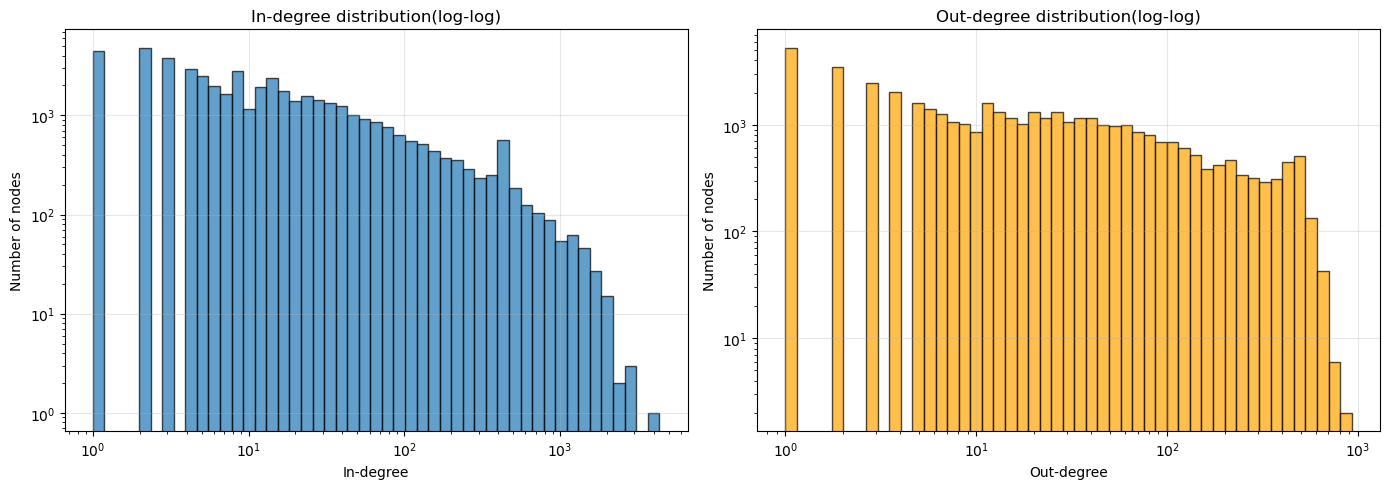

STATISTICHE IN-DEGREE
Nodi con in-degree = 0:   1,100 (2.3%)
Nodi con in-degree < 10:  25,956 (53.4%)
Nodi con in-degree < 100: 44,283 (91.1%)
Nodi con in-degree >= 100: 4,347 (8.9%)

STATISTICHE OUT-DEGREE
Nodi con out-degree = 0:   5,161 (10.6%)
Nodi con out-degree < 10:  24,769 (50.9%)
Nodi con out-degree < 100: 43,150 (88.7%)
Nodi con out-degree >= 100: 5,480 (11.3%)


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# PLOT IN-DEGREE DISTRIBUTION (log-log)
# =============================================
in_values = list(in_deg.values())
out_values = list(out_deg.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In-degree histogram con bin logaritmici
in_values_nonzero = [v for v in in_values if v > 0]
bins_in = np.logspace(0, np.log10(max(in_values_nonzero)), 50)
axes[0].hist(in_values_nonzero, bins=bins_in, edgecolor='black', alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('In-degree')
axes[0].set_ylabel('Number of nodes')
axes[0].set_title('In-degree distribution(log-log)')
axes[0].grid(True, alpha=0.3)

# Out-degree histogram con bin logaritmici
out_values_nonzero = [v for v in out_values if v > 0]
bins_out = np.logspace(0, np.log10(max(out_values_nonzero)), 50)
axes[1].hist(out_values_nonzero, bins=bins_out, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Out-degree')
axes[1].set_ylabel('Number of nodes')
axes[1].set_title('Out-degree distribution(log-log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('degree_distribution_loglog.png', dpi=150)
plt.show()

# =============================================
# STATISTICHE: Frazioni di nodi per soglie
# =============================================
n_nodes = len(in_deg)

print("=" * 60)
print("STATISTICHE IN-DEGREE")
print("=" * 60)
print(f"Nodi con in-degree = 0:   {sum(1 for v in in_values if v == 0):,} ({100*sum(1 for v in in_values if v == 0)/n_nodes:.1f}%)")
print(f"Nodi con in-degree < 10:  {sum(1 for v in in_values if v < 10):,} ({100*sum(1 for v in in_values if v < 10)/n_nodes:.1f}%)")
print(f"Nodi con in-degree < 100: {sum(1 for v in in_values if v < 100):,} ({100*sum(1 for v in in_values if v < 100)/n_nodes:.1f}%)")
print(f"Nodi con in-degree >= 100: {sum(1 for v in in_values if v >= 100):,} ({100*sum(1 for v in in_values if v >= 100)/n_nodes:.1f}%)")

print("\n" + "=" * 60)
print("STATISTICHE OUT-DEGREE")
print("=" * 60)
print(f"Nodi con out-degree = 0:   {sum(1 for v in out_values if v == 0):,} ({100*sum(1 for v in out_values if v == 0)/n_nodes:.1f}%)")
print(f"Nodi con out-degree < 10:  {sum(1 for v in out_values if v < 10):,} ({100*sum(1 for v in out_values if v < 10)/n_nodes:.1f}%)")
print(f"Nodi con out-degree < 100: {sum(1 for v in out_values if v < 100):,} ({100*sum(1 for v in out_values if v < 100)/n_nodes:.1f}%)")
print(f"Nodi con out-degree >= 100: {sum(1 for v in out_values if v >= 100):,} ({100*sum(1 for v in out_values if v >= 100)/n_nodes:.1f}%)")

### Centralità di grado (normalizzata)

- `nx.in_degree_centrality(G)`
- `nx.out_degree_centrality(G)`

**Costo:** ~O(|E|)

In [5]:
in_deg_cent  = nx.in_degree_centrality(G)
out_deg_cent = nx.out_degree_centrality(G)

# Top-10
sorted(in_deg_cent.items(), key=lambda x: x[1], reverse=True)[:10], sorted(out_deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

([(1179270258, 0.08939110407370088),
  (1479163323, 0.0765592547656748),
  (1136479756, 0.05833967385716342),
  (1387645188, 0.05784614119147011),
  (1459035940, 0.05418577392091139),
  (1417136285, 0.05052540665035267),
  (1200497997, 0.046412634436241745),
  (1390659157, 0.04489090871702071),
  (1225790696, 0.04427399288490407),
  (1335927003, 0.04371876863599909)],
 [(1335904171, 0.019042135351333565),
  (1160507923, 0.017335334882477533),
  (1368365091, 0.01589586460753871),
  (1379886235, 0.0158547368853976),
  (1365860979, 0.015340640358633736),
  (1367422246, 0.014538649776882106),
  (1475145200, 0.014538649776882106),
  (1442233413, 0.01441526661045878),
  (1279459175, 0.014333011166176562),
  (1474120050, 0.014312447305106007)])

## 3) Componenti connesse (molto importanti)

Nei grafi diretti si usa spesso:

- **SCC** (*Strongly Connected Components*): nodi mutuamente raggiungibili seguendo le direzioni.
- **WCC** (*Weakly Connected Components*): connettività ignorando l'orientamento.

**Costo:** ~O(|V| + |E|) (fattibile anche su grafi grandi)

In [6]:
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))

num_scc = len(scc)
num_wcc = len(wcc)

largest_scc = max(scc, key=len)
largest_wcc = max(wcc, key=len)

num_scc, len(largest_scc), num_wcc, len(largest_wcc)

(11622, 36386, 384, 48222)

In [7]:
# =============================================
# DETAILED CONNECTED COMPONENTS ANALYSIS
# =============================================
# This block analyzes WCC (Weakly Connected Components) and SCC (Strongly Connected Components)
# to understand the graph structure and implications for the crawler.
# - WCC: groups of nodes reachable ignoring edge direction
# - SCC: groups where EVERY node can reach EVERY other following edge directions
# If seeds are outside the Giant SCC, the crawler may not reach many groups.

print("=" * 60)
print("CONNECTED COMPONENTS ANALYSIS")
print("=" * 60)

# Get number of nodes for percentage calculations
total_nodes = G.number_of_nodes()

# ---- WCC Analysis ----
# wcc_sizes: list of component sizes, sorted descending
# Example: [1116361, 50, 30, 20, 10, ...] → giant component + small ones
wcc_sizes_sorted = sorted([len(component) for component in wcc], reverse=True)

print(f"\nWEAKLY CONNECTED COMPONENTS (WCC):")
print(f"  Total components: {num_wcc}")
print(f"  Giant WCC: {wcc_sizes_sorted[0]:,} nodes ({100*wcc_sizes_sorted[0]/total_nodes:.1f}%)")

if len(wcc_sizes_sorted) > 1:
    print(f"  2nd component: {wcc_sizes_sorted[1]:,} nodes ({100*wcc_sizes_sorted[1]/total_nodes:.1f}%)")
if len(wcc_sizes_sorted) > 2:
    print(f"  3rd component: {wcc_sizes_sorted[2]:,} nodes ({100*wcc_sizes_sorted[2]/total_nodes:.1f}%)")
if len(wcc_sizes_sorted) > 3:
    print(f"  4th component: {wcc_sizes_sorted[3]:,} nodes ({100*wcc_sizes_sorted[3]/total_nodes:.1f}%)")
if len(wcc_sizes_sorted) > 4:
    print(f"  5th component: {wcc_sizes_sorted[4]:,} nodes ({100*wcc_sizes_sorted[4]/total_nodes:.1f}%)")

print(f"  Top 10 component sizes: {wcc_sizes_sorted[:10]}")

# ---- SCC Analysis ----
# scc_sizes: list of component sizes, sorted descending
# Example: [85361, 2, 2, 2, 1, 1, ...] → one medium component + many singletons
scc_sizes_sorted = sorted([len(component) for component in scc], reverse=True)

print(f"\nSTRONGLY CONNECTED COMPONENTS (SCC):")
print(f"  Total components: {num_scc}")
print(f"  Giant SCC: {scc_sizes_sorted[0]:,} nodes ({100*scc_sizes_sorted[0]/total_nodes:.1f}%)")

if len(scc_sizes_sorted) > 1:
    print(f"  2nd component: {scc_sizes_sorted[1]:,} nodes ({100*scc_sizes_sorted[1]/total_nodes:.1f}%)")
if len(scc_sizes_sorted) > 2:
    print(f"  3rd component: {scc_sizes_sorted[2]:,} nodes ({100*scc_sizes_sorted[2]/total_nodes:.1f}%)")
if len(scc_sizes_sorted) > 3:
    print(f"  4th component: {scc_sizes_sorted[3]:,} nodes ({100*scc_sizes_sorted[3]/total_nodes:.1f}%)")
if len(scc_sizes_sorted) > 4:
    print(f"  5th component: {scc_sizes_sorted[4]:,} nodes ({100*scc_sizes_sorted[4]/total_nodes:.1f}%)")

print(f"  Top 10 component sizes: {scc_sizes_sorted[:10]}")

# ---- Implications for the crawler ----
print("\n" + "=" * 60)
print("IMPLICATIONS FOR THE CRAWLER")
print("=" * 60)
print(f"• {100*wcc_sizes_sorted[0]/total_nodes:.1f}% of nodes are in Giant WCC → network is connected (ignoring directions)")
print(f"• Only {100*scc_sizes_sorted[0]/total_nodes:.1f}% are in Giant SCC → few nodes are mutually reachable")
print(f"• If seeds are OUTSIDE the SCC, the crawler may not reach many groups")
print(f"• There are {num_wcc} separate WCC components: if all seeds are in one, others are unreachable")

CONNECTED COMPONENTS ANALYSIS

WEAKLY CONNECTED COMPONENTS (WCC):
  Total components: 384
  Giant WCC: 48,222 nodes (99.2%)
  2nd component: 3 nodes (0.0%)
  3rd component: 3 nodes (0.0%)
  4th component: 3 nodes (0.0%)
  5th component: 2 nodes (0.0%)
  Top 10 component sizes: [48222, 3, 3, 3, 2, 2, 2, 2, 2, 2]

STRONGLY CONNECTED COMPONENTS (SCC):
  Total components: 11622
  Giant SCC: 36,386 nodes (74.8%)
  2nd component: 17 nodes (0.0%)
  3rd component: 15 nodes (0.0%)
  4th component: 12 nodes (0.0%)
  5th component: 12 nodes (0.0%)
  Top 10 component sizes: [36386, 17, 15, 12, 12, 11, 10, 8, 8, 7]

IMPLICATIONS FOR THE CRAWLER
• 99.2% of nodes are in Giant WCC → network is connected (ignoring directions)
• Only 74.8% are in Giant SCC → few nodes are mutually reachable
• If seeds are OUTSIDE the SCC, the crawler may not reach many groups
• There are 384 separate WCC components: if all seeds are in one, others are unreachable


## 4) PageRank (chiave nei grafi diretti)

- `nx.pagerank(G)` calcola un punteggio di importanza dei nodi.
- È un metodo **iterativo**.

**Costo:** ~O(k·|E|) dove *k* è il numero di iterazioni.  
Su grafi grandi può essere costoso: controlla `max_iter` e `tol`.

In [8]:
# =============================================
# PAGERANK 
# =============================================

pr = nx.pagerank(G, max_iter=100, tol=1e-6)

top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
top_pr

[(1472892297, 0.003477405970602263),
 (1392160803, 0.0021345230574174867),
 (1006503122, 0.0018439964034215343),
 (1003099698, 0.0017312547591434684),
 (1179270258, 0.0014053712640501106),
 (1126704851, 0.0013511265041318012),
 (1009232144, 0.0012554292937492302),
 (1000170429, 0.0012096496480927075),
 (1117426017, 0.0011529135427803022),
 (1387645188, 0.0011014160868745618)]

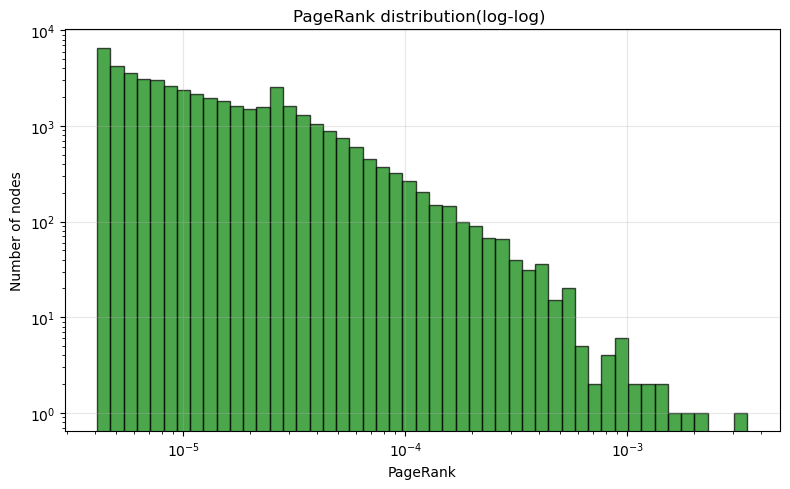

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# PLOT PAGERANK DISTRIBUTION (log-log)
# =============================================
pr_values = list(pr.values())

fig, ax = plt.subplots(figsize=(8, 5))

# Bin logaritmici
pr_values_nonzero = [v for v in pr_values if v > 0]
bins_pr = np.logspace(np.log10(min(pr_values_nonzero)), np.log10(max(pr_values_nonzero)), 50)
ax.hist(pr_values_nonzero, bins=bins_pr, edgecolor='black', alpha=0.7, color='green')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('PageRank')
ax.set_ylabel('Number of nodes')
ax.set_title('PageRank distribution(log-log) ')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pagerank_distribution_loglog.png', dpi=150)
plt.show()

## 5) HITS (hub e authority)

- `nx.hits(G)` restituisce due dizionari: **hubs** e **authorities**.
- Anche questo è **iterativo**.

**Costo:** ~O(k·|E|)  
Su grafi grandi può essere costoso e talvolta più instabile di PageRank.

In [10]:
hubs, auth = nx.hits(G, max_iter=1000, tol=1e-8)

top_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:100]
top_auth = sorted(auth.items(), key=lambda x: x[1], reverse=True)[:100]

print("top hubs")
print(top_hubs)
print("top auth")
print(top_auth)

top hubs
[(1318275860, 0.002182173060742191), (1254182474, 0.0021630543239200945), (1215834055, 0.002158074153766244), (1444621361, 0.002157998152133669), (1220662131, 0.0021558978688205398), (1461240728, 0.002153491828662728), (1282935538, 0.0021514002404058757), (1185780966, 0.002149364423480071), (1435525948, 0.002148983056296121), (1473948950, 0.002148974967843771), (1406723745, 0.0021487229620988533), (1131982808, 0.0021476698292872457), (1474829003, 0.0021458858611153628), (1212645245, 0.0021456496454860963), (1438107544, 0.002143118948113055), (1277748571, 0.002142719966792812), (1429752245, 0.0021424499430611125), (1423331110, 0.0021414602783270506), (1266913635, 0.0021414265288425007), (1222332129, 0.002140935475137166), (1268652025, 0.0021408783604164607), (1429896781, 0.002140693700558488), (1518283341, 0.002140658061479261), (1453773802, 0.002139225437163538), (1191729277, 0.0021388965972086223), (1215908225, 0.0021388319562806062), (1434407928, 0.002138523168966841), (1288

In [11]:
# ============================================================
# INTERSEZIONE TRA TOP HUB E TOP AUTHORITY
# ============================================================
# Prendi i top 100 (o altro numero) per entrambe le metriche
TOP_N = 10

# Set dei top hub (canali che forwardano molto verso canali importanti)
top_hubs_ids = set([node for node, score in sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:TOP_N]])

# Set dei top authority (canali da cui si forwarda molto)
top_auth_ids = set([node for node, score in sorted(auth.items(), key=lambda x: x[1], reverse=True)[:TOP_N]])

# Intersezione: canali che sono ENTRAMBI top hub E top authority
hub_and_authority = top_hubs_ids & top_auth_ids

print(f"Top {TOP_N} Hub: {len(top_hubs_ids)}")
print(f"Top {TOP_N} Authority: {len(top_auth_ids)}")
print(f"Intersezione (hub ∩ authority): {len(hub_and_authority)}")
print(f"Percentuale intersezione: {100*len(hub_and_authority)/TOP_N:.1f}%")

if hub_and_authority:
    print(f"\nCanali nell'intersezione: {list(hub_and_authority)[:20]}...")  # Mostra primi 20

Top 10 Hub: 10
Top 10 Authority: 10
Intersezione (hub ∩ authority): 0
Percentuale intersezione: 0.0%


## 9) Cicli e DAG

- `nx.is_directed_acyclic_graph(G)` verifica se il grafo è un **DAG** (nessun ciclo diretto).  
  **Costo:** ~O(|V|+|E|)

- `nx.simple_cycles(G)` elenca i cicli semplici.  
  **Costo:** potenzialmente **esponenziale** 👉 evitare su grafi grandi.

In [12]:
is_dag = nx.is_directed_acyclic_graph(G)
is_dag

False

## 10) Reciprocità (utile e leggera)

Misura quanto gli archi sono spesso **bidirezionali**.

- `nx.reciprocity(G)` -> valore globale (0..1 circa)

**Costo:** ~O(|E|) (molto fattibile)

In [13]:
nx.reciprocity(G)

0.2162849739476801

In [14]:
# =============================================
# TELEGRAM LINKS FOR MANUAL INVESTIGATION
# =============================================
# This block provides channel IDs for manual investigation.
# 
# Note: Telegram channel_ids cannot be directly converted to links.
# To investigate, you need to either:
# 1. Use Telegram API (telethon/pyrogram) to get username/title from ID
# 2. Search the ID on sites like tgstat.com or similar

# ---- Define top 20 for each metric ----
# top20_pagerank: list of tuples [(node_id, score), ...]
# Example: [(1004035975, 0.00132), (1064404455, 0.00118), ...]
top20_pagerank = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:20]
top20_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:20]
top20_authorities = sorted(auth.items(), key=lambda x: x[1], reverse=True)[:20]

# ---- Extract just the node IDs as sets (for comparison later) ----
# Example: {1004035975, 1064404455, 1433940064, ...}
top20_pagerank_ids = set([node_id for node_id, score in top20_pagerank])
top20_hub_ids = set([node_id for node_id, score in top20_hubs])
top20_authority_ids = set([node_id for node_id, score in top20_authorities])

print("=" * 70)
print("CHANNEL IDs FOR MANUAL INVESTIGATION")
print("=" * 70)

print("\nNote: Telegram channel_ids are numeric and cannot be directly")
print("converted to links without using the Telegram API.")
print("\nTo investigate these channels, you can:")
print("  1. Use Telegram API (telethon) to get username/title from ID")
print("  2. Search the ID on tgstat.com or similar services")
print("  3. Use a bot like @username_to_id_bot (reverse lookup)")

# ---- Top 10 PageRank IDs ----
print("\n--- TOP 10 PAGERANK (to investigate) ---")
for rank, (node_id, score) in enumerate(top20_pagerank[:10], 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"  {rank}. Channel ID: {node_id} (in:{node_in_degree}, out:{node_out_degree})")

# ---- Top 10 Hub IDs ----
print("\n--- TOP 10 HUBS (to investigate) ---")
for rank, (node_id, score) in enumerate(top20_hubs[:10], 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"  {rank}. Channel ID: {node_id} (in:{node_in_degree}, out:{node_out_degree})")

# ---- Top 10 Authority IDs ----
print("\n--- TOP 10 AUTHORITIES (to investigate) ---")
for rank, (node_id, score) in enumerate(top20_authorities[:10], 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"  {rank}. Channel ID: {node_id} (in:{node_in_degree}, out:{node_out_degree})")

# ---- Summary of unique channels to investigate ----
all_top_ids = top20_pagerank_ids | top20_hub_ids | top20_authority_ids
print(f"\n--- SUMMARY ---")
print(f"Total unique channels in top 20 of any metric: {len(all_top_ids)}")

CHANNEL IDs FOR MANUAL INVESTIGATION

Note: Telegram channel_ids are numeric and cannot be directly
converted to links without using the Telegram API.

To investigate these channels, you can:
  1. Use Telegram API (telethon) to get username/title from ID
  2. Search the ID on tgstat.com or similar services
  3. Use a bot like @username_to_id_bot (reverse lookup)

--- TOP 10 PAGERANK (to investigate) ---
  1. Channel ID: 1472892297 (in:761, out:1)
  2. Channel ID: 1392160803 (in:1945, out:1)
  3. Channel ID: 1006503122 (in:1760, out:1)
  4. Channel ID: 1003099698 (in:68, out:14)
  5. Channel ID: 1179270258 (in:4347, out:0)
  6. Channel ID: 1126704851 (in:856, out:4)
  7. Channel ID: 1009232144 (in:1704, out:11)
  8. Channel ID: 1000170429 (in:273, out:4)
  9. Channel ID: 1117426017 (in:462, out:1)
  10. Channel ID: 1387645188 (in:2813, out:7)

--- TOP 10 HUBS (to investigate) ---
  1. Channel ID: 1318275860 (in:458, out:483)
  2. Channel ID: 1254182474 (in:446, out:476)
  3. Channel ID:

In [15]:
# =============================================
# MANUAL INVESTIGATION: TOP NODES BY PAGERANK, HUB, AUTHORITY
# =============================================
# This block prints detailed tables and compares overlap between metrics.
# Goal: understand if top Hubs are also top Authorities, or if they differ.
# 
# Reminder (in this graph, edge A→B means B forwarded from A):
# - Hub: node whose content is forwarded a lot (high out-degree)
# - Authority: node that forwards from many good sources (high in-degree)

# =============================================
# CONFIGURATION: Set how many top nodes to analyze
# =============================================
TOP_N = 700  # ← CHANGE THIS VALUE TO ANALYZE MORE OR FEWER NODES

# ---- Define top N for each metric ----
# top_n_pagerank: list of tuples [(node_id, score), ...]
# Example: [(1004035975, 0.00132), (1064404455, 0.00118), ...]
top_n_pagerank = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
top_n_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
top_n_authorities = sorted(auth.items(), key=lambda x: x[1], reverse=True)[:TOP_N]

# ---- Extract just the node IDs as sets (for comparison) ----
# Example: {1004035975, 1064404455, 1433940064, ...}
top_n_pagerank_ids = set([node_id for node_id, score in top_n_pagerank])
top_n_hub_ids = set([node_id for node_id, score in top_n_hubs])
top_n_authority_ids = set([node_id for node_id, score in top_n_authorities])

print("=" * 70)
print(f"TOP {TOP_N} NODES BY PAGERANK, HUB, AUTHORITY")
print("=" * 70)

# ---- Print top N PageRank with in/out degree ----
print(f"\n--- TOP {TOP_N} PAGERANK ---")
print(f"{'Rank':<5} {'Node ID':<15} {'PageRank':<12} {'In-degree':<12} {'Out-degree':<12}")
print("-" * 56)
for rank, (node_id, score) in enumerate(top_n_pagerank, 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"{rank:<5} {node_id:<15} {score:<12.6f} {node_in_degree:<12} {node_out_degree:<12}")

# ---- Print top N Hubs with in/out degree ----
print(f"\n--- TOP {TOP_N} HUBS ---")
print(f"{'Rank':<5} {'Node ID':<15} {'Hub Score':<12} {'In-degree':<12} {'Out-degree':<12}")
print("-" * 56)
for rank, (node_id, score) in enumerate(top_n_hubs, 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"{rank:<5} {node_id:<15} {score:<12.6f} {node_in_degree:<12} {node_out_degree:<12}")

# ---- Print top N Authorities with in/out degree ----
print(f"\n--- TOP {TOP_N} AUTHORITIES ---")
print(f"{'Rank':<5} {'Node ID':<15} {'Auth Score':<12} {'In-degree':<12} {'Out-degree':<12}")
print("-" * 56)
for rank, (node_id, score) in enumerate(top_n_authorities, 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"{rank:<5} {node_id:<15} {score:<12.6f} {node_in_degree:<12} {node_out_degree:<12}")

# =============================================
# COMPARISON: Are top Hubs also top Authorities?
# =============================================
print("\n" + "=" * 70)
print(f"COMPARISON: TOP {TOP_N} HUBS vs TOP {TOP_N} AUTHORITIES")
print("=" * 70)

# Set operations to find overlap and differences
nodes_in_both_hub_and_auth = top_n_hub_ids & top_n_authority_ids  # intersection
nodes_only_in_hub = top_n_hub_ids - top_n_authority_ids           # hub but not authority
nodes_only_in_auth = top_n_authority_ids - top_n_hub_ids          # authority but not hub

print(f"\nNodes in BOTH top {TOP_N} (Hub AND Authority): {len(nodes_in_both_hub_and_auth)}")
print(f"Nodes ONLY in top {TOP_N} Hubs: {len(nodes_only_in_hub)}")
print(f"Nodes ONLY in top {TOP_N} Authorities: {len(nodes_only_in_auth)}")

if len(nodes_in_both_hub_and_auth) > 0:
    print(f"\nNode IDs in common: {nodes_in_both_hub_and_auth}")
else:
    print(f"\n→ Top {TOP_N} Hubs and top {TOP_N} Authorities are DISTINCT groups!")

# ---- Comparison across all three metrics ----
print("\n" + "=" * 70)
print(f"COMPARISON: PAGERANK vs HUB vs AUTHORITY (TOP {TOP_N})")
print("=" * 70)

overlap_pr_hub = top_n_pagerank_ids & top_n_hub_ids
overlap_pr_auth = top_n_pagerank_ids & top_n_authority_ids
overlap_hub_auth = top_n_hub_ids & top_n_authority_ids
overlap_all_three = top_n_pagerank_ids & top_n_hub_ids & top_n_authority_ids

print(f"PageRank ∩ Hub: {len(overlap_pr_hub)} nodes in common")
print(f"PageRank ∩ Authority: {len(overlap_pr_auth)} nodes in common")
print(f"Hub ∩ Authority: {len(overlap_hub_auth)} nodes in common")
print(f"All three metrics: {len(overlap_all_three)} nodes in common")

if len(overlap_all_three) > 0:
    print(f"\nNodes in ALL three top {TOP_N}: {overlap_all_three}")

# ---- Summary ----
all_top_ids = top_n_pagerank_ids | top_n_hub_ids | top_n_authority_ids
print(f"\n--- SUMMARY ---")
print(f"Total unique channels in top {TOP_N} of any metric: {len(all_top_ids)}")

TOP 700 NODES BY PAGERANK, HUB, AUTHORITY

--- TOP 700 PAGERANK ---
Rank  Node ID         PageRank     In-degree    Out-degree  
--------------------------------------------------------
1     1472892297      0.003477     761          1           
2     1392160803      0.002135     1945         1           
3     1006503122      0.001844     1760         1           
4     1003099698      0.001731     68           14          
5     1179270258      0.001405     4347         0           
6     1126704851      0.001351     856          4           
7     1009232144      0.001255     1704         11          
8     1000170429      0.001210     273          4           
9     1117426017      0.001153     462          1           
10    1387645188      0.001101     2813         7           
11    1137657151      0.001002     1133         4           
12    1244077735      0.001001     1883         1           
13    1200497997      0.000963     2257         7           
14    1479163323     

In [ ]:
# =============================================
# INVESTIGATE TOP NODES: PAGERANK, HUB, AUTHORITY
# =============================================
# This cell allows manual investigation of top channels.
# Shows preprocessing info (English message count) for each channel.
#
# Data structure example:
# channels_config = {
#     1004035975: {
#         'n_messages': 15,
#         'selection': 'random',
#         'metrics': ['pagerank', 'hub'],
#         'english_msg_count': 156,  # From preprocessing
#     },
# }

import json
import os
import random
from collections import defaultdict
from datetime import datetime

# =============================================
# CONFIGURATION
# =============================================
TGDATASET_DIR = "../../material"
EXTRACTED_DIR = f"{TGDATASET_DIR}/TGDataset_extracted"
MAPPING_FILE = f"{TGDATASET_DIR}/channel_file_mapping.json"
LABELED_FILE = f"{TGDATASET_DIR}/TGDataset/labeled_data/ch_to_topic_mapping.csv"

# How many top nodes to investigate for each metric
TOP_N_TO_INVESTIGATE = 10

# How many messages to extract per channel
N_MESSAGES = 15

# Selection mode: 'first', 'last', 'random'
SELECTION_MODE = 'random'

# =============================================
# BUILD CHANNELS CONFIG DICTIONARY
# =============================================
# Structure: {channel_id: {'n_messages': int, 'selection': str, 'metrics': list, ...}}
channels_config = {}

# Add top PageRank nodes
for rank, (node_id, score) in enumerate(top_n_pagerank[:TOP_N_TO_INVESTIGATE], 1):
    if node_id not in channels_config:
        channels_config[node_id] = {
            'n_messages': N_MESSAGES,
            'selection': SELECTION_MODE,
            'metrics': [],
            'in_degree': in_deg.get(node_id, 0),
            'out_degree': out_deg.get(node_id, 0),
            'english_msg_count': channel_english_count.get(node_id, 0),  # From preprocessing
        }
    channels_config[node_id]['metrics'].append('pagerank')
    channels_config[node_id]['pagerank_rank'] = rank
    channels_config[node_id]['pagerank_score'] = score

# Add top Hub nodes
for rank, (node_id, score) in enumerate(top_n_hubs[:TOP_N_TO_INVESTIGATE], 1):
    if node_id not in channels_config:
        channels_config[node_id] = {
            'n_messages': N_MESSAGES,
            'selection': SELECTION_MODE,
            'metrics': [],
            'in_degree': in_deg.get(node_id, 0),
            'out_degree': out_deg.get(node_id, 0),
            'english_msg_count': channel_english_count.get(node_id, 0),
        }
    channels_config[node_id]['metrics'].append('hub')
    channels_config[node_id]['hub_rank'] = rank
    channels_config[node_id]['hub_score'] = score

# Add top Authority nodes
for rank, (node_id, score) in enumerate(top_n_authorities[:TOP_N_TO_INVESTIGATE], 1):
    if node_id not in channels_config:
        channels_config[node_id] = {
            'n_messages': N_MESSAGES,
            'selection': SELECTION_MODE,
            'metrics': [],
            'in_degree': in_deg.get(node_id, 0),
            'out_degree': out_deg.get(node_id, 0),
            'english_msg_count': channel_english_count.get(node_id, 0),
        }
    channels_config[node_id]['metrics'].append('authority')
    channels_config[node_id]['authority_rank'] = rank
    channels_config[node_id]['authority_score'] = score

print(f"Channels to investigate: {len(channels_config)}")
print(f"  - From PageRank top {TOP_N_TO_INVESTIGATE}")
print(f"  - From Hub top {TOP_N_TO_INVESTIGATE}")
print(f"  - From Authority top {TOP_N_TO_INVESTIGATE}")

# =============================================
# LOAD CHANNEL MAPPING AND LABELS
# =============================================
print("\nLoading channel mapping...")
with open(MAPPING_FILE, 'r') as f:
    channel_mapping = json.load(f)

print("Loading ground truth labels...")
labels_df = pd.read_csv(LABELED_FILE)
channel_labels = dict(zip(labels_df['ch_ID'], labels_df['topic']))

print(f"  Channels in mapping: {len(channel_mapping):,}")
print(f"  Channels with labels: {len(channel_labels):,}")

# =============================================
# FUNCTION: LOAD CHANNEL DATA FROM TGDATASET
# =============================================
def load_channel_data(channel_id, channel_mapping, extracted_dir):
    """
    Load channel data from TGDataset extracted files.
    
    Returns dict with keys: 'title', 'username', 'text_messages', 'total_messages'
    """
    ch_id_str = str(channel_id)
    
    if ch_id_str not in channel_mapping:
        return None
    
    file_path = channel_mapping[ch_id_str]['file']
    full_path = f"{extracted_dir}/{file_path}"
    
    if not os.path.exists(full_path):
        return None
    
    try:
        with open(full_path, 'r') as f:
            data = json.load(f)
        
        if ch_id_str in data:
            channel_data = data[ch_id_str]
            return {
                'title': channel_data.get('title', '[no title]'),
                'username': channel_data.get('username', '[no username]'),
                'text_messages': channel_data.get('text_messages', {}),
                'total_messages': len(channel_data.get('text_messages', {})),
            }
    except Exception as e:
        print(f"  [ERROR] Failed to load channel {channel_id}: {e}")
    
    return None

# =============================================
# FUNCTION: SELECT MESSAGES
# =============================================
def select_messages(text_messages, n_messages, selection_mode):
    """
    Select messages from a channel based on configuration.
    Returns list of (msg_id, msg_data) tuples, sorted by date.
    """
    if not text_messages:
        return []
    
    msg_items = list(text_messages.items())
    msg_items_sorted = sorted(msg_items, key=lambda x: x[1].get('date', 0))
    
    n_available = len(msg_items_sorted)
    n_to_select = min(n_messages, n_available)
    
    if selection_mode == 'first':
        selected = msg_items_sorted[:n_to_select]
    elif selection_mode == 'last':
        selected = msg_items_sorted[-n_to_select:]
    elif selection_mode == 'random':
        selected = random.sample(msg_items_sorted, n_to_select)
        selected = sorted(selected, key=lambda x: x[1].get('date', 0))
    else:
        selected = msg_items_sorted[:n_to_select]
    
    return selected

# =============================================
# INVESTIGATE EACH CHANNEL
# =============================================
print("\n" + "=" * 80)
print("CHANNEL INVESTIGATION")
print("=" * 80)

investigation_results = {}

for channel_id, config in channels_config.items():
    print(f"\n{'─' * 80}")
    
    # Header with metrics
    metrics_str = ', '.join(config['metrics']).upper()
    print(f"CHANNEL {channel_id} [{metrics_str}]")
    print(f"{'─' * 80}")
    
    # Print metric rankings
    for metric in config['metrics']:
        rank = config.get(f'{metric}_rank', '?')
        score = config.get(f'{metric}_score', 0)
        print(f"  {metric.capitalize()}: Rank #{rank}, Score: {score:.6f}")
    
    # Print degree info
    print(f"  In-degree: {config['in_degree']:,}")
    print(f"  Out-degree: {config['out_degree']:,}")
    
    # Print preprocessing info
    english_count = config['english_msg_count']
    preprocess_status = "✓ VALID" if english_count >= MIN_CHANNEL_MESSAGES else f"✗ INVALID (< {MIN_CHANNEL_MESSAGES})"
    print(f"  English messages: {english_count} {preprocess_status}")
    
    # Check if labeled
    gt_label = channel_labels.get(channel_id, '[NOT LABELED]')
    print(f"  Ground Truth Label: {gt_label}")
    
    # Load channel data
    channel_data = load_channel_data(channel_id, channel_mapping, EXTRACTED_DIR)
    
    if channel_data is None:
        print(f"  [WARNING] Channel not found in TGDataset")
        investigation_results[channel_id] = {
            'config': config,
            'label': gt_label,
            'found': False,
        }
        continue
    
    print(f"  Title: {channel_data['title']}")
    print(f"  Username: @{channel_data['username']}")
    print(f"  Total messages in dataset: {channel_data['total_messages']:,}")
    
    # Select messages
    selected_messages = select_messages(
        channel_data['text_messages'],
        config['n_messages'],
        config['selection']
    )
    
    print(f"\n  MESSAGES ({len(selected_messages)} {config['selection']}, max {config['n_messages']}):")
    print(f"  {'─' * 70}")
    
    for msg_id, msg_data in selected_messages:
        msg_text = msg_data.get('message', '[no text]')
        msg_date = msg_data.get('date', 0)
        fwd_from = msg_data.get('forwarded_from_id', None)
        
        # Format date
        if msg_date:
            date_str = datetime.fromtimestamp(msg_date).strftime('%Y-%m-%d %H:%M')
        else:
            date_str = '[no date]'
        
        # Truncate message
        msg_display = msg_text[:300] if msg_text else '[empty]'
        if len(msg_text) > 300:
            msg_display += "..."
        
        # Forward indicator
        fwd_str = f" [FWD from {fwd_from}]" if fwd_from else ""
        
        print(f"    [{date_str}]{fwd_str}")
        print(f"    {msg_display}")
        print()
    
    # Store results
    investigation_results[channel_id] = {
        'config': config,
        'label': gt_label,
        'found': True,
        'title': channel_data['title'],
        'username': channel_data['username'],
        'total_messages': channel_data['total_messages'],
        'english_msg_count': english_count,
    }

# =============================================
# SUMMARY
# =============================================
print("\n" + "=" * 80)
print("INVESTIGATION SUMMARY")
print("=" * 80)

found_count = sum(1 for r in investigation_results.values() if r['found'])
labeled_count = sum(1 for r in investigation_results.values() if r['label'] != '[NOT LABELED]')

print(f"\nChannels investigated: {len(investigation_results)}")
print(f"  Found in TGDataset: {found_count}")
print(f"  Not found: {len(investigation_results) - found_count}")
print(f"  With GT label: {labeled_count}")

# Preprocessing status
valid_count = sum(1 for ch_id, r in investigation_results.items() 
                  if channels_config[ch_id]['english_msg_count'] >= MIN_CHANNEL_MESSAGES)
print(f"  Valid (>= {MIN_CHANNEL_MESSAGES} English msgs): {valid_count}")
print(f"  Invalid (< {MIN_CHANNEL_MESSAGES} English msgs): {len(investigation_results) - valid_count}")

# By metric
print("\nBy metric:")
for metric in ['pagerank', 'hub', 'authority']:
    count = sum(1 for ch_id, r in investigation_results.items() 
                if metric in channels_config[ch_id]['metrics'])
    print(f"  {metric.capitalize()}: {count} channels")


Channels to investigate: 30
  - From PageRank top 10
  - From Hub top 10
  - From Authority top 10

Loading channel mapping...
Loading ground truth labels...
  Channels in mapping: 120,979
  Channels with labels: 19,768

CHANNEL INVESTIGATION

────────────────────────────────────────────────────────────────────────────────
CHANNEL 1472892297 [PAGERANK]
────────────────────────────────────────────────────────────────────────────────
  Pagerank: Rank #1, Score: 0.003477
  In-degree: 761
  Out-degree: 1
  English messages: 10 ✓ VALID
  Ground Truth Label: Religion
  Title: MTRK ǀ Rasmiy kanal
  Username: @mtrkuzofficial
  Total messages in dataset: 34,878

  MESSAGES (15 random, max 15):
  ──────────────────────────────────────────────────────────────────────
    [2021-12-01 13:43]
    **Факт 24 | Полиэтилен экспортига оид статистик рақамлар
**#1dec #uzbekiston24

[mtrk.uz](https://mtrk.uz/) | [Youtube](https://www.youtube.com/channel/UCWCThSM0ntBV9lQQ4PnIesg) | [Facebook](https://www.fac